In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import zipfile

with zipfile.ZipFile('/content/drive/MyDrive/cse144/train.zip', 'r') as z:
    z.extractall('/content/')
with zipfile.ZipFile('/content/drive/MyDrive/cse144/test.zip', 'r') as z:
    z.extractall('/content/')

In [ ]:
# Imports + init seed
import os, random
import numpy as np
import torch
import torch.nn as nn
import pandas as pd
from PIL import Image
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms
from torchvision.models import vit_b_16, ViT_B_16_Weights

SEED = 41
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
# Data augmentation
train_transforms = transforms.Compose([
    transforms.Resize((384, 384)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.RandomRotation(20),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.3),
])

val_transforms = transforms.Compose([
    transforms.Resize((384, 384)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# dataset = datasets.ImageFolder('/content/train/', transform=train_transforms)
full_dataset_train = datasets.ImageFolder('/content/train/', transform=train_transforms)
full_dataset_val   = datasets.ImageFolder('/content/train/', transform=val_transforms)

# Fix labels so folder name == label integer
for ds in [full_dataset_train, full_dataset_val]:
    ds.class_to_idx = {cls: int(cls) for cls in ds.classes}
    ds.samples = [
        (path, int(os.path.basename(os.path.dirname(path))))
        for path, _ in ds.samples
    ]
    ds.targets = [s[1] for s in ds.samples]

n = len(full_dataset_train)
indices = list(range(n))
random.shuffle(indices)
val_size = int(0.2 * n)
train_idx, val_idx = indices[val_size:], indices[:val_size]

train_set = Subset(full_dataset_train, train_idx)
val_set = Subset(full_dataset_val, val_idx)

train_loader = DataLoader(train_set, batch_size=32, shuffle=True,  num_workers=2)
val_loader = DataLoader(val_set, batch_size=32, shuffle=False, num_workers=2)

print(f"Train: {len(train_set)} | Val: {len(val_set)}")

Train: 864 | Val: 215


In [ ]:
model = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_SWAG_E2E_V1)

# Replace final layer for 100 classes
model.heads.head = nn.Linear(model.heads.head.in_features, 100)
model = model.to(device)

print("done")

done


In [ ]:
def mixup_data(x, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    idx = torch.randperm(x.size(0)).to(x.device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam

def mixup_criterion(pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

In [ ]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

def run_epoch(model, loader, optimizer=None, use_mixup=False):
    training = optimizer is not None
    model.train() if training else model.eval()
    total_loss, correct, n = 0, 0, 0
    with torch.set_grad_enabled(training):
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            if training and use_mixup:
                imgs, y_a, y_b, lam = mixup_data(imgs, labels)
                out = model(imgs)
                loss = mixup_criterion(out, y_a, y_b, lam)
            else:
                out = model(imgs)
                loss = criterion(out, labels)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item()
            correct += (out.argmax(1) == labels).sum().item()
            n += labels.size(0)
    return total_loss / len(loader), correct / n

In [ ]:
for param in model.parameters():
    param.requires_grad = False

for param in model.heads.parameters():
    param.requires_grad = True

print(model.heads.head.weight.requires_grad)

optimizer = torch.optim.AdamW(model.heads.parameters(), lr=1e-3, weight_decay=1e-4)

for epoch in range(5):
    tl, ta = run_epoch(model, train_loader, optimizer)
    vl, va = run_epoch(model, val_loader)
    print(f"Epoch {epoch+1}- Train acc: {ta:.2%}, Val acc: {va:.2%}")

True
Epoch 1- Train acc: 17.01%, Val acc: 35.35%
Epoch 2- Train acc: 50.12%, Val acc: 48.84%
Epoch 3- Train acc: 65.28%, Val acc: 58.60%
Epoch 4- Train acc: 68.75%, Val acc: 61.40%
Epoch 5- Train acc: 75.69%, Val acc: 65.12%


In [ ]:
for param in model.parameters():
    param.requires_grad = True

optimizer = torch.optim.AdamW([
    {"params": model.encoder.parameters(), "lr": 1e-5},
    {"params": model.heads.parameters(), "lr": 1e-4},
], weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=60)

best_val_acc = 0
train_accs = []
val_accs = []
for epoch in range(60):
    tl, ta = run_epoch(model, train_loader, optimizer, use_mixup=True)
    vl, va = run_epoch(model, val_loader)
    scheduler.step()
    print(f"Epoch {epoch+1}- Train acc: {ta:.2%}, Val acc: {va:.2%}")
    train_accs.append(ta)
    val_accs.append(va)
    if va > best_val_acc:
        best_val_acc = va
        torch.save(model.state_dict(), '/content/drive/MyDrive/cse144/best_model.pth')
        print(f"BEST MODEL HAS VALIDATION ACCURACY: {va:.2%})")

Epoch 1- Train acc: 29.51%, Val acc: 67.91%
BEST MODEL HAS VALIDATION ACCURACY: 67.91%)
Epoch 2- Train acc: 34.72%, Val acc: 70.23%
BEST MODEL HAS VALIDATION ACCURACY: 70.23%)
Epoch 3- Train acc: 46.99%, Val acc: 74.88%
BEST MODEL HAS VALIDATION ACCURACY: 74.88%)
Epoch 4- Train acc: 27.89%, Val acc: 72.56%
Epoch 5- Train acc: 36.81%, Val acc: 68.84%
Epoch 6- Train acc: 60.30%, Val acc: 73.95%
Epoch 7- Train acc: 40.05%, Val acc: 73.02%
Epoch 8- Train acc: 50.81%, Val acc: 75.35%
BEST MODEL HAS VALIDATION ACCURACY: 75.35%)
Epoch 9- Train acc: 55.32%, Val acc: 74.42%
Epoch 10- Train acc: 51.27%, Val acc: 76.28%
BEST MODEL HAS VALIDATION ACCURACY: 76.28%)
Epoch 11- Train acc: 57.18%, Val acc: 76.28%
Epoch 12- Train acc: 47.45%, Val acc: 76.28%
Epoch 13- Train acc: 41.78%, Val acc: 73.02%
Epoch 14- Train acc: 55.56%, Val acc: 75.81%
Epoch 15- Train acc: 37.04%, Val acc: 77.67%
BEST MODEL HAS VALIDATION ACCURACY: 77.67%)
Epoch 16- Train acc: 44.56%, Val acc: 77.21%
Epoch 17- Train acc: 34.4

In [ ]:
print("Retraining on full dataset")

full_loader = DataLoader(full_dataset_train, batch_size=32, shuffle=True, num_workers=2)

model.load_state_dict(torch.load('/content/drive/MyDrive/cse144/best_model.pth'))

optimizer_full = torch.optim.AdamW([
    {"params": model.encoder.parameters(),  "lr": 1e-5},
    {"params": model.heads.parameters(),    "lr": 1e-4},
], weight_decay=1e-4)
scheduler_full = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_full, T_max=30)

for epoch in range(30):
    tl, ta = run_epoch(model, full_loader, optimizer_full, use_mixup=True)
    scheduler_full.step()
    print(f"[Full retrain] Epoch {epoch+1} | Train {ta:.2%}")

torch.save(model.state_dict(), '/content/drive/MyDrive/cse144/best_model_full.pth')

test_transforms_tta = transforms.Compose([
    transforms.Resize((384, 384)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.RandomRotation(20),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

test_transforms_base = transforms.Compose([
    transforms.Resize((384, 384)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

model.load_state_dict(torch.load('/content/drive/MyDrive/cse144/best_model_full.pth'))
model.eval()

test_dir = '/content/test/'
test_files = sorted(os.listdir(test_dir), key=lambda x: int(x.split('.')[0]))

TTA_RUNS = 60
results = []

with torch.no_grad():
    for fname in test_files:
        img = Image.open(os.path.join(test_dir, fname)).convert("RGB")
        probs = torch.zeros(100).to(device)
        probs += torch.softmax(model(test_transforms_base(img).unsqueeze(0).to(device)), dim=1).squeeze()
        for _ in range(TTA_RUNS):
            probs += torch.softmax(model(test_transforms_tta(img).unsqueeze(0).to(device)), dim=1).squeeze()
        results.append({"ID": fname, "Label": probs.argmax().item()})

submission = pd.DataFrame(results)
submission.to_csv('/content/drive/MyDrive/cse144/submission.csv', index=False)
print("Done!")
print(submission.head(10))

Retraining on full dataset
[Full retrain] Epoch 1 | Train 46.25%
[Full retrain] Epoch 2 | Train 44.11%
[Full retrain] Epoch 3 | Train 42.08%
[Full retrain] Epoch 4 | Train 37.26%
[Full retrain] Epoch 5 | Train 45.60%
[Full retrain] Epoch 6 | Train 50.51%
[Full retrain] Epoch 7 | Train 66.17%
[Full retrain] Epoch 8 | Train 49.68%
[Full retrain] Epoch 9 | Train 45.69%
[Full retrain] Epoch 10 | Train 67.19%
[Full retrain] Epoch 11 | Train 42.26%
[Full retrain] Epoch 12 | Train 43.56%
[Full retrain] Epoch 13 | Train 50.51%
[Full retrain] Epoch 14 | Train 45.88%
[Full retrain] Epoch 15 | Train 57.83%
[Full retrain] Epoch 16 | Train 61.82%
[Full retrain] Epoch 17 | Train 60.43%
[Full retrain] Epoch 18 | Train 70.25%
[Full retrain] Epoch 19 | Train 34.29%
[Full retrain] Epoch 20 | Train 43.65%
[Full retrain] Epoch 21 | Train 55.24%
[Full retrain] Epoch 22 | Train 62.84%
[Full retrain] Epoch 23 | Train 39.02%
[Full retrain] Epoch 24 | Train 53.20%
[Full retrain] Epoch 25 | Train 57.37%
[Full r

In [ ]:
print(torch.__version__)

2.11.0+cu128


60
60


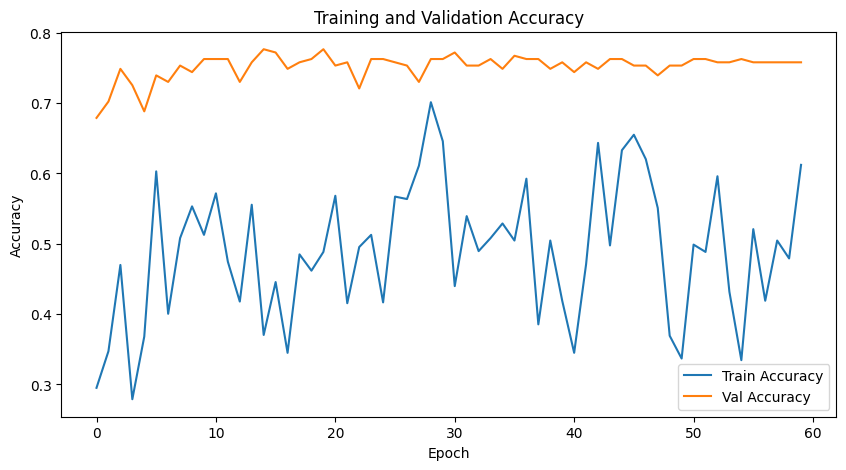

In [ ]:
import matplotlib.pyplot as plt

print(len(train_accs))
print(len(val_accs))
plt.figure(figsize=(10, 5))
plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.savefig('/content/drive/MyDrive/cse144/training_curve.png')
plt.show()